In [1]:
#need to change all code to 2d
from random import seed
from random import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import numpy as np
from scipy.optimize import curve_fit
def fit_func(x, a, b):
    return a*x + b

In [2]:
def temporal_sporulation_3d(g0=1,densitymax=1,cc=1,k0=0.1,d=1,\
                           ngnotinput=0,nknotinput=1,\
                           gammainput=1,uinput=0):
    g=g0 #growth rate
    k=k0 #sporulation rate
    D=d
    c=densitymax
    dt=0.0001 #timestep
    u=uinput # used to plot continuous graph for different gamma
    lengthscale=300 #proposed length of growing space

    #checkpoint for looping
    checkpoint=300 #could be time
    
    #varying properties
    phi=np.zeros(lengthscale) #cell percent
    spore=np.zeros(lengthscale) #spore percent
    speed=np.zeros(lengthscale) #localspeed
    rv=np.zeros(lengthscale)
    rvroua=np.zeros(lengthscale)
    space=np.linspace(0,lengthscale,lengthscale)
    
    #radius
    rovertime=[] #
    rsimu=[] #
    rsimutip=[] #
    sumrecorded=[] #total amount of cells, used to analytical derive radius
    
    #time
    timerecorded=[]
    timenow=0
    
    #speed at the tip
    speedmax=[]
    
    #initial condition
    phi[0]=1
    spore[0]=0
    R=((sum(phi)+sum(spore))/(c))**(1/3) #outer radius based on initial condition
    edge=np.floor(R)
    effgrowth=g+phi*0
    effsporulation=k+spore*0
    i=1
    while i<=edge:
        speed[i]=speed[i-1]+phi[i-1]*effgrowth[i-1]
        rv[i]=rv[i-1]+effgrowth[i-1]*phi[i-1]*(3*i*i-3*i+1)/(3*c)
        #rvroua[i]=rvroua[i-1]+effgrowth[i-1]*phi[i-1]*(i+i-1)/2
        i=i+1
        
    #looping
    while checkpoint>0:
        gradientphi=np.zeros(lengthscale)
        fluxphi=np.zeros(lengthscale)
        fluxspore=np.zeros(lengthscale)
        #nutrientpp=np.zeros(lengthscale)
        rovertime.append(R)
        rsimu.append(np.argmax(phi))
        loc=int(edge)
        sumv= (rv[loc]+effgrowth[loc]*phi[loc]*(3*loc*loc+3*loc+1)/(3*c))/(R*R)#sum(effgrowth*phi)
        #radius recording
        i=len(phi)-1
        while i>0:
            if phi[i]+spore[i]<=0:
                i=i-1
            else:
                break
        rsimutip.append(i)
        timerecorded.append(timenow)
        sumrecorded.append(sum(phi)+sum(spore))
        
        #finding gradient/flux
        i=0
        while i<len(phi):
            if i==0:
                fluxphi[i]=(phi[i]*rv[i+1])/(i*i+i+1/3)
                fluxspore[i]=(spore[i]*rv[i+1])/(i*i+i+1/3)
                #nutrientpp[i]=nutrient[i+1]-nutrient[i]
            elif i==len(phi)-1:
                fluxphi[i]=(phi[i]*rv[i]-phi[i-1]*rv[i])/(i*i+i+1/3)
                fluxspore[i]=(spore[i]*rv[i]-spore[i-1]*rv[i])/(i*i+i+1/3)
                #nutrientpp[i]=nutrient[i-1]-nutrient[i]
            else:
                fluxphi[i]=(phi[i]*rv[i+1]-phi[i-1]*rv[i])/(i*i+i+1/3)
                fluxspore[i]=(spore[i]*rv[i+1]-spore[i-1]*rv[i])/(i*i+i+1/3)
                #nutrientpp[i]=nutrient[i-1]+nutrient[i+1]-2*nutrient[i]
            i=i+1
        phinew=phi+dt*(phi*effgrowth-effsporulation*phi-fluxphi)
        sporenew=spore+dt*(effsporulation*phi-fluxspore)
        #nutrientnew=nutrient+(D*nutrientpp-phi*effgrowth*gamma)*dt
        Rnew=R+sumv*dt
        R=Rnew
        timenow=timenow+dt
        #print(u)
        #if timenow>u:
        #    plt.figure(u)
        #    plt.plot(space,phi,"r-",label="cell percent")
        #    plt.plot(space,spore,"g-",label="spore density")
            #plt.plot(space,nutrient,"m-",label="nutrient")
         #   plt.xlabel("distance")
         #   plt.ylabel("density")
            
            #plt.plot(space,pressure,"c-",label="pressure")
            #plt.plot(space,speed,"y-",label="velocity")
            #plt.axvline(x = R, color = 'b', label = 'Biofilm edge')
            #plt.axvline(x = np.argmax(phinew), color = 'm', label = 'simulated Biofilm edge')
           # plt.legend()
            #plt.savefig("temporal growth "+str("g=1,k=0.3,time= ")+str(u)+".pdf")
           # plt.show()

           # u=u+1
        phi=phinew
        spore=sporenew
        #nutrient=nutrientnew
        edge=np.floor(R)
        
        effgrowth=g+phi*0
        effsporulation=k+spore*0
        if edge<lengthscale:
            i=1
            while i<=edge:
                speed[i]=speed[i-1]+phi[i-1]*effgrowth[i-1]
                rv[i]=rv[i-1]+effgrowth[i-1]*phi[i-1]*(3*i*i-3*i+1)/(3*c)
                i=i+1
        else:
            checkpoint=0
            
        checkpoint=checkpoint-dt
        if phi[len(phi)-100]>0.1:
            checkpoint=0
            
    plt.figure(u)
    #calculation for speed
    i=0
    speedovertime=[]
    speedott=[]
    tovert=[]
    
    while i+1<len(rsimu):
        speedovertime.append((rsimu[i+1]-rsimu[i])/(timerecorded[i+1]-timerecorded[i]))
        tovert.append(timerecorded[i])
        i=i+1
    i=0
    while i+1<len(rsimutip):
        speedott.append((rsimutip[i+1]-rsimutip[i])/(timerecorded[i+1]-timerecorded[i]))
        i=i+1
    #speedrecorded
    #plt.plot(timerecorded,rovertime,"b-",label="estimated")
    plt.plot(timerecorded,rsimutip,"m-",label="simulation")
    avrou=sum(phi)/R
    rcor=1/c-3*(g/(c*(g-k)))*(1/3)
    anatip=((g/(c*(g-k)))*np.exp(np.array(timerecorded)*(g-k))+rcor)**(1/3)#(((g)/(g-k))**(0.5))*np.exp(np.array(timerecorded)*(g-k)/2)
            #np.exp(np.array(timerecorded)*(sum(effgrowth)/len(effgrowth))*avrou/2)*1
    #plt.plot(timerecorded,sumrecorded,"b-",label="amount of biomass")
    #plt.plot(timerecorded,rovertime,"b-",label="estimated")
    plt.plot(timerecorded,anatip,"b-",label="analytic estimated")
    plt.legend()
    plt.xlabel("time")
    plt.ylabel("radius--length of biofilm")
    #plt.savefig("radius temporal growth "+str("g=1,k=0.3,time= ")+str(u)+".pdf")
    plt.show()
    u=u+1
    #plt.figure(u)
    #plt.plot(timerecorded,anatip-rsimutip,"b-",label="difference")
    #plt.plot(tovert,speedovertime)
    #u=u+1
    plt.figure(u)
    plt.plot(space,phi,"r-",label="cell percent")
    plt.plot(space,spore,"g-",label="spore density")
    #plt.plot(space,nutrient,"p-",label="nutrient")
    plt.xlim(0,lengthscale)
    plt.xlabel("distance")
    plt.ylabel("density")
    plt.ylim(0,1.1)
    plt.legend()
    #plt.savefig("temporal growth "+str("g=1,k=0.3,time= ")+str(u)+".pdf")
    plt.show()
    u=u+1
    
    return phi,spore,timerecorded,sumrecorded,rsimu,rsimutip,anatip,speedovertime,speedmax,speedott,u

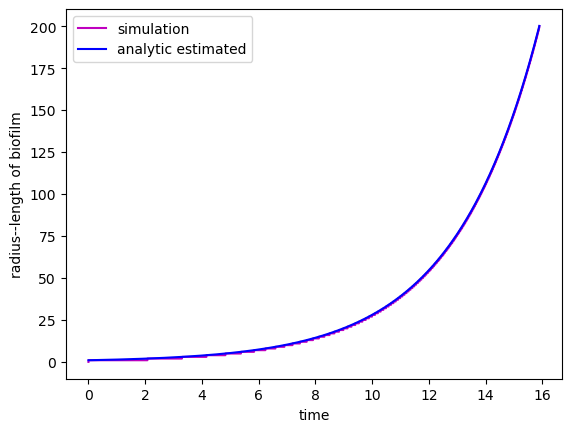

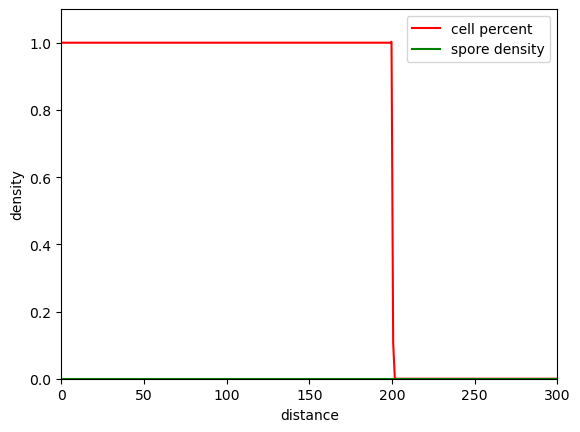

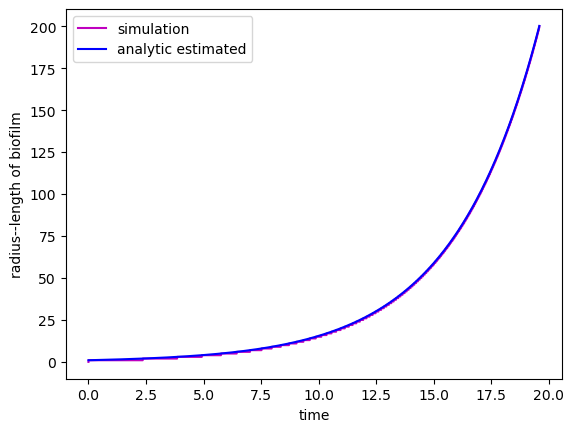

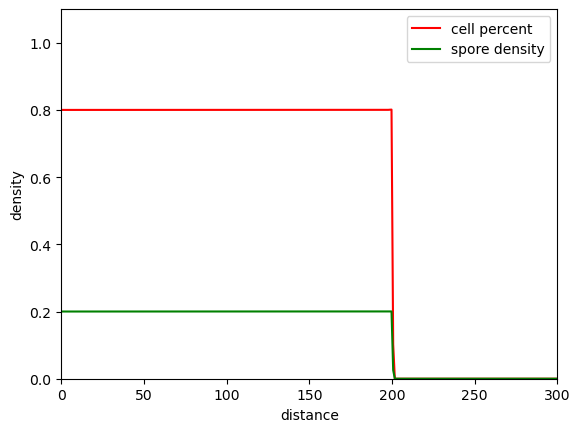

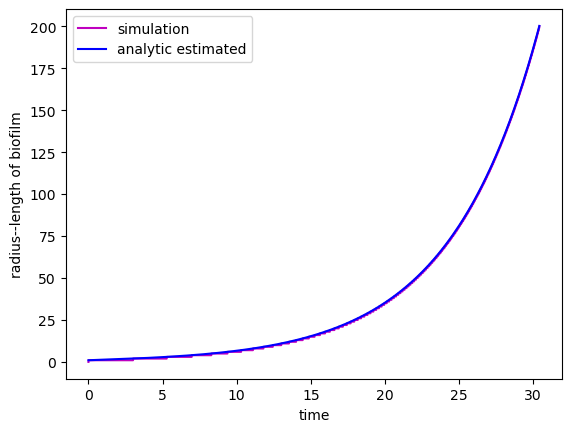

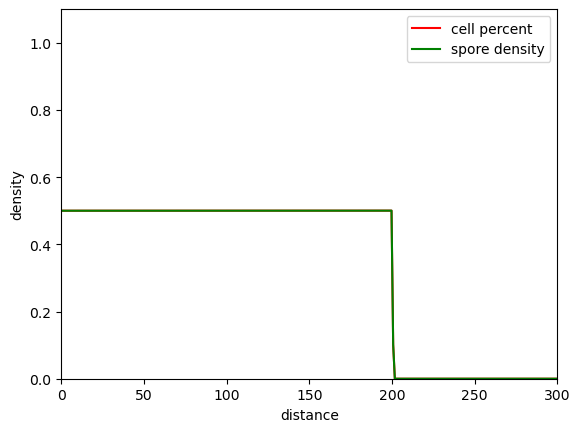

In [3]:
kval=np.array([0,0.2,0.5]) 
plotrsim=[]
plotran=[]
plottime=[]
i=0
u=0
while i <len(kval):
    
    phi3,spore3,timerecorded3,sumrecorded3,\
    rsimu3,rsimutip3,anatip3,speedovertime3,speedmax3,speedott3,u3\
    =temporal_sporulation_3d(g0=1,densitymax=1,k0=kval[i],d=1,\
                       ngnotinput=0,nknotinput=1,\
                       gammainput=0,uinput=u)
    plotrsim.append(rsimutip3)
    plotran.append(anatip3)
    plottime.append(timerecorded3)
    u=u3
    i=i+1

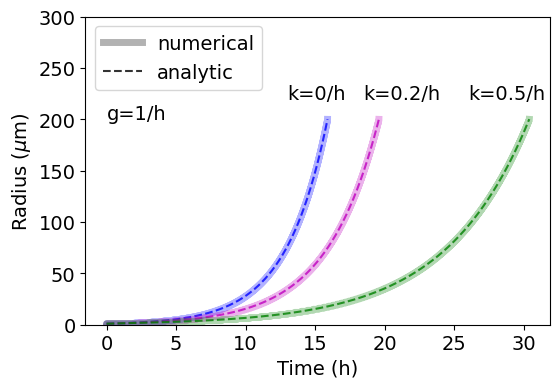

In [5]:
#plt.figure(1)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams['font.size'] = 14
legend_elements = [Line2D([0], [0], color='k', lw=5, alpha=0.3,label='numerical'),
                   Line2D([0], [0], linestyle='--',color='k', alpha=0.8, label='analytic')]

# Create the figure
fig, ax = plt.subplots(figsize=(6,4))
ax.legend(handles=legend_elements, loc='upper left',frameon=True)

i=0
cl=['b','m','g']
while i<len(plotrsim):
    plt.plot(plottime[i],plotrsim[i],color=cl[i],linestyle='-',alpha=0.3,linewidth=5)
    plt.plot(plottime[i],plotran[i],color=cl[i],linestyle='--',alpha=0.8)
    i=i+1
#plt.legend()

first = []
second = []
plt.plot(first, 'b-', second, 'b--')
#plt.legend(['simulation', 'analytic'], loc='upper left')
#plt.title("Sporulation Timer-1D")
plt.xlabel(r"Time (h)")
plt.ylabel(r"Radius ($\mu$m)")
plt.ylim(0,300)
plt.text(13,220,"k=0/h")
plt.text(18.5,220,"k=0.2/h")
plt.text(26,220,"k=0.5/h")
plt.text(0,200,"g=1/h")
plt.savefig("3d-timer-different-k"+".png",bbox_inches = 'tight',dpi=300)